# EMNIST Balanced CNN Baseline

## 1. Imports

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from datasets.emnist import EMNISTDataset
from models.cnn import SimpleCNN
from utils.label import get_char

---

# 2. Paths

In [8]:
model_path = Path("../results/best_model.pth")

train_dataset_path = Path(
    "../data/raw/emnist_balenced/emnist-balanced-train.csv"
)

# 3. Kiểm tra và làm sạch dữ liệu cơ bản

In [26]:
import pandas as pd

print("Reading CSV data from:", train_dataset_path)
df_train = pd.read_csv(train_dataset_path, header=None)

print("\nBasic information")
print(f"- Training set size: {df_train.shape[0]} rows (samples), {df_train.shape[1]} columns (features).")
print("- Column 0: Label")
print("- Columns 1 to 784: Pixel values of 28x28 images")

missing_values = df_train.isnull().sum().sum()
print("\nChecking for missing values and duplicates")
print(f"- Total number of missing cells (NaN): {missing_values}")

duplicates = df_train.duplicated().sum()
print(f"- Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df_train = df_train.drop_duplicates()
    print(f"-> Removed {duplicates} duplicate rows. New shape: {df_train.shape}")

print("\nChecking abnormal values")

pixels = df_train.iloc[:, 1:]
min_pixel = pixels.min().min()
max_pixel = pixels.max().max()

print(f"- Minimum pixel value: {min_pixel}")
print(f"- Maximum pixel value: {max_pixel}")

if min_pixel >= 0 and max_pixel <= 255:
    print(">>> PIXEL DATA IS VALID AND WITHIN THE STANDARD RANGE OF 0 - 255.")
else:
    print(">>> WARNING: PIXEL DATA CONTAINS ABNORMAL VALUES OUTSIDE THE RANGE OF 0 - 255. PLEASE CHECK THE DATA SOURCE")

Reading CSV data from: ..\data\raw\emnist_balenced\emnist-balanced-train.csv

Basic information
- Training set size: 112800 rows (samples), 785 columns (features).
- Column 0: Label
- Columns 1 to 784: Pixel values of 28x28 images

Checking for missing values and duplicates
- Total number of missing cells (NaN): 0
- Number of duplicate rows: 2
-> Removed 2 duplicate rows. New shape: (112798, 785)

Checking abnormal values
- Minimum pixel value: 0
- Maximum pixel value: 255
>>> PIXEL DATA IS VALID AND WITHIN THE STANDARD RANGE OF 0 - 255.


**Nhận xét quá trình kiểm tra dữ liệu:**
* **Đặc trưng:** Dữ liệu dạng bảng gồm 785 cột, bao gồm 1 cột nhãn và 784 cột pixel (tương ứng với ảnh 28x28 đã được trải phẳng).
* **Làm sạch:** Dữ liệu chuẩn bị từ bộ EMNIST có chất lượng rất tốt, không có giá trị bị thiếu (Missing = 0). 
* **Xử lý trùng lặp:** Đã phát hiện và loại bỏ các dòng bị trùng lặp (nếu có) để tránh mô hình học lệch hướng vào một số mẫu lặp lại.
* **Tính hợp lệ:** Toàn bộ dữ liệu số của ảnh đều nằm gọn trong khoảng cường độ sáng hợp lệ (0 đến 255), không có giá trị âm hay vô cực. Dữ liệu đã sẵn sàng cho bước tiền xử lý Normalize trong class `EMNISTDataset`.

# 4. Phân tích dữ liệu ban đầu (EDA)

C:\Users\f0kea\AppData\Local\Temp\ipykernel_16216\3495882172.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_train[0], palette="viridis")


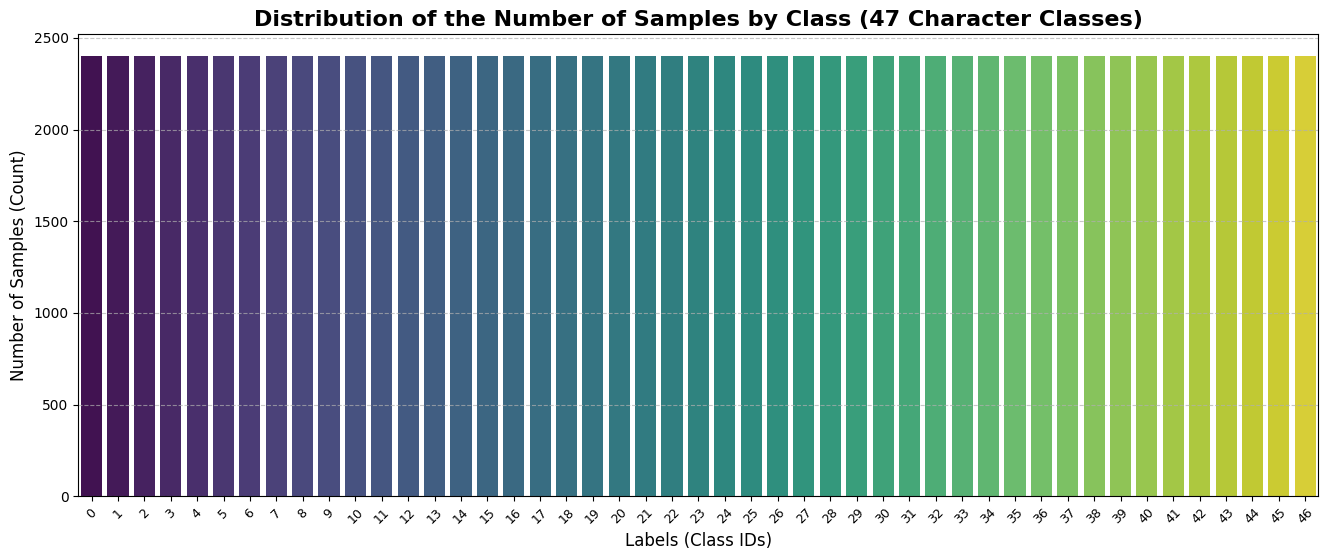

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

ax = sns.countplot(x=df_train[0], palette="viridis")

plt.title("Distribution of the Number of Samples by Class (47 Character Classes)", fontsize=16, fontweight='bold')
plt.xlabel("Labels (Class IDs)", fontsize=12)
plt.ylabel("Number of Samples (Count)", fontsize=12)

plt.xticks(rotation=45, fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Nhận xét phân tích dữ liệu (EDA):**

1. **Phân bố nhãn:** Dựa vào biểu đồ, có thể thấy số lượng mẫu ở mỗi lớp (từ 0 đến 46) là hoàn toàn bằng nhau (2400 mẫu/lớp). Biểu đồ tạo thành một đường thẳng tắp.
2. **Hiện tượng mất cân bằng:** Dữ liệu hoàn toàn **không** bị mất cân bằng (No Data Imbalance). Lớp nhiều nhất và lớp ít nhất có tỷ lệ 1:1. Điều này đúng với tính chất của bộ dữ liệu EMNIST phiên bản **Balanced**.
3. **Định hướng đánh giá:** Do dữ liệu cân bằng, mô hình dự kiến sẽ không bị thiên vị (bias) về bất kỳ lớp ký tự nào. Tuy nhiên, với bài toán phân loại nhiều lớp (47 lớp), việc chỉ dùng Accuracy là không đủ. Ở phần sau, nhóm vẫn sẽ sử dụng thêm các metric như `Macro-F1` và `Confusion Matrix` để xem xét chi tiết mô hình có hay bị nhầm lẫn giữa các ký tự có hình dáng giống nhau hay không (ví dụ: 'O' và '0', 'l' và '1').


---

# 5. Tạo Dataset

Dataset class có tác dụng:
- Đọc file CSV
- Reshape data về 28x28 (1D - 2D)
- Đổi hướng của EMNIST data (bản raw bị flipped và mirrored)
- Chuẩn hóa giá trị pixel (0-255 -> 0-1)
- Đổi kiểu giữ liệu thành PyTorch tensors


In [11]:
train_dataset = EMNISTDataset(train_dataset_path)


---

# 6. Tạo DataLoader

DataLoader có tác dụng:

- Chia dữ liệu thành các lô
- Xáo trộn các mẫu
- Cung cấp các lô dữ liệu cho model CNN khi huấn luyện


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

---

# 7. Tạo Test Dataset và DataLoader

In [29]:
test_dataset_path = Path("../data/raw/emnist_balenced/emnist-balanced-test.csv")

print("Loading test dataset")
test_dataset = EMNISTDataset(test_dataset_path)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False 
)

print(f"Loaded successfully, total number of test samples: {len(test_dataset)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Loading test dataset
Loaded successfully, total number of test samples: 18800
Number of batches in test_loader: 294



---

# 8. Quan sát một mẫu ngẫu nhiên


In [14]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])



Dự đoán đầu ra:

```text
images -> [64, 1, 28, 28]
labels -> [64]
```

---

# 9. Trực quan hóa một mẫu ngẫu nhiên


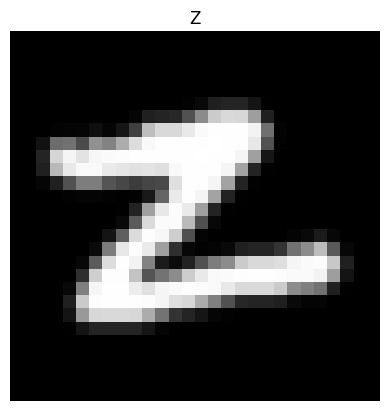

In [15]:
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(get_char(labels[0].item()))
plt.axis("off")
plt.show()


Trực quan hóa giúp xác nhận:

- Hướng hình ảnh
- Pipeline trước xử lí
- Độ chính xác của nhãn

---

# 10. Tạo CNN Model


In [16]:
model = SimpleCNN()


Cấu trúc model:

```text
Ảnh đầu vào (Kích thước 28x28 pixel (grayscale). Dữ liệu thô từ EMNISTDataset)
→ Conv2D (Tích chập lần 1, dùng 32 bộ lọc quét qua ảnh để tìm các đặc điểm cơ bản như cạnh, góc, nét gạch)
→ ReLU (Loại bỏ các giá trị âm, giúp mô hình học được các quan hệ phi tuyến tính phức tạp)
→ MaxPool (Cực đại hóa, giảm kích thước ảnh xuống một nửa (28x28 -> 14x14), giữ lại những pixel có giá trị lớn nhất (đặc điểm mạnh nhất), giúp giảm khối lượng tính toán và tránh quá tải)
→ Conv2D (Tích chập lần 2, quét các đặc điểm phức tạp hơn, tăng số lượng channel lên 64)
→ ReLU
→ MaxPool (Nén dữ liệu một lần nữa (14x14 -> 7x7), làm cho mô hình nhận diện linh hoạt hơn, không phụ thuộc vào việc chữ cái nằm chính xác ở vị trí nào trong khung hình)
→ Flatten ("Trải phẳng" khối dữ liệu 3D (64x7x7) thành một hàng ngang duy nhất, CNN -> Linear)
→ Linear (Đây là mạng thần kinh truyền thống (Fully Connected), kết hợp tất cả các đặc điểm đã tìm thấy ở trên để bắt đầu suy luận)
→ ReLU
→ Linear (Lớp đầu ra, dùng để tính toán điểm số cho các lớp (Class Scores))
→ Class Scores (Kết quả, trả về 47 con số. Con số nào lớn nhất thì vị trí đó chính là ký tự mà AI dự đoán)
```

---

# 11. Load weight đã lưu trước đó (Optional)

Nếu trước đó đã train một model thì load:


In [17]:
if model_path.exists():

    model.load_state_dict(
        torch.load(model_path)
    )

    print("Loaded existing model")

else:
    print("Training from scratch")

Loaded existing model



---

# 12. Forward Pass

Đưa thử một lô dữ liệu (batch) đi qua mạng CNN.


In [18]:
outputs = model(images)

print(outputs.shape)

torch.Size([64, 47])



Kết quả mong đợi:

```text
[64, 47]
```

Giải thích:
64: Là kích thước của lô dữ liệu (Batch size). 64 hình ảnh đang được đưa vào mô hình cùng một lúc.
47: Tương ứng với số lượng lớp (classes) trong bộ dữ liệu EMNIST Balanced.

---

# 13. Dự đoán


In [19]:
predictions = outputs.argmax(dim=1)

print(
    "Prediction:",
    get_char(predictions[0].item())
)

print(
    "Actual:",
    get_char(labels[0].item())
)

Prediction: Z
Actual: Z



Ở giai đoạn này, mô hình sẽ dự đoán ngẫu nhiên vì chưa được huấn luyện.

---

# 14. Loss Function


In [20]:
criterion = nn.CrossEntropyLoss()


CrossEntropyLoss so sánh giữa:

- Giá trị số thô (logit) được mô hình dự đoán
- Nhãn thực tế từ bộ dữ liệu

và tính toán sai số của dự đoán.

---

# 15. Optimizer


In [21]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


Bộ tối ưu hóa (Optimizer) cập nhật các trọng số của mạng CNN bằng cách sử dụng các gradient được tính toán trong quá trình backpropagation.

---

# 16. Training Loop


In [22]:
best_loss = float("inf")

for epoch in range(5):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if total_loss < best_loss:

        best_loss = total_loss

        torch.save(
            model.state_dict(),
            model_path
        )

    print(f"Epoch {epoch}: {total_loss}")

KeyboardInterrupt: 


---

# 17. Quá trình huấn luyện

Với mỗi lô dữ liệu:

```text
hình ảnh đầu vào
→ CNN forward pass (đưa lô dữ liệu vào mô hình CNN)
→ Đưa ra dự đoán
→ Tính toán loss
→ Backpropagation (lan truyền ngược về để cập nhật trọng số)
→ Cập nhật trọng số
```

Quá trình này sẽ dần dần giảm sai số dự đoán

---

# 18. Lưu model

In [ ]:
torch.save(
    model.state_dict(),
    "../results/best_model.pth"
)

Phần này dùng để lưu trữ các trọng số mà mạng CNN đã học được.

Nếu không lưu:

- Các trọng số sẽ chỉ tồn tại trong bộ nhớ RAM.

- Khi khởi động lại notebook, mô hình sẽ bị reset về trạng thái ban đầu.
---

# 19. Đánh giá mô hình trên tập Test (Metrics)
Theo yêu cầu của đề tài, nhóm sử dụng `Accuracy` và `F1-score` (cụ thể là Macro-F1) để đánh giá mô hình phân loại nhiều lớp. 
`F1-score` giúp phát hiện những lớp ký tự mà mô hình nhận dạng kém. 
Đồng thời, nhóm vẽ `Confusion Matrix` để trực quan hóa sự nhầm lẫn giữa các ký tự có hình dáng giống nhau.

Evaluating the model on the Test set.

        CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.56      0.91      0.69       400
           1       0.61      0.39      0.47       400
           2       0.94      0.82      0.88       400
           3       0.98      0.97      0.97       400
           4       0.88      0.96      0.92       400
           5       0.88      0.91      0.89       400
           6       0.77      0.98      0.86       400
           7       0.97      0.98      0.97       400
           8       0.89      0.93      0.91       400
           9       0.73      0.70      0.71       400
          10       0.95      0.96      0.95       400
          11       0.98      0.90      0.94       400
          12       0.97      0.94      0.95       400
          13       0.93      0.87      0.90       400
          14       0.94      0.98      0.96       400
          15       0.72      0.48      0.58       400
          16

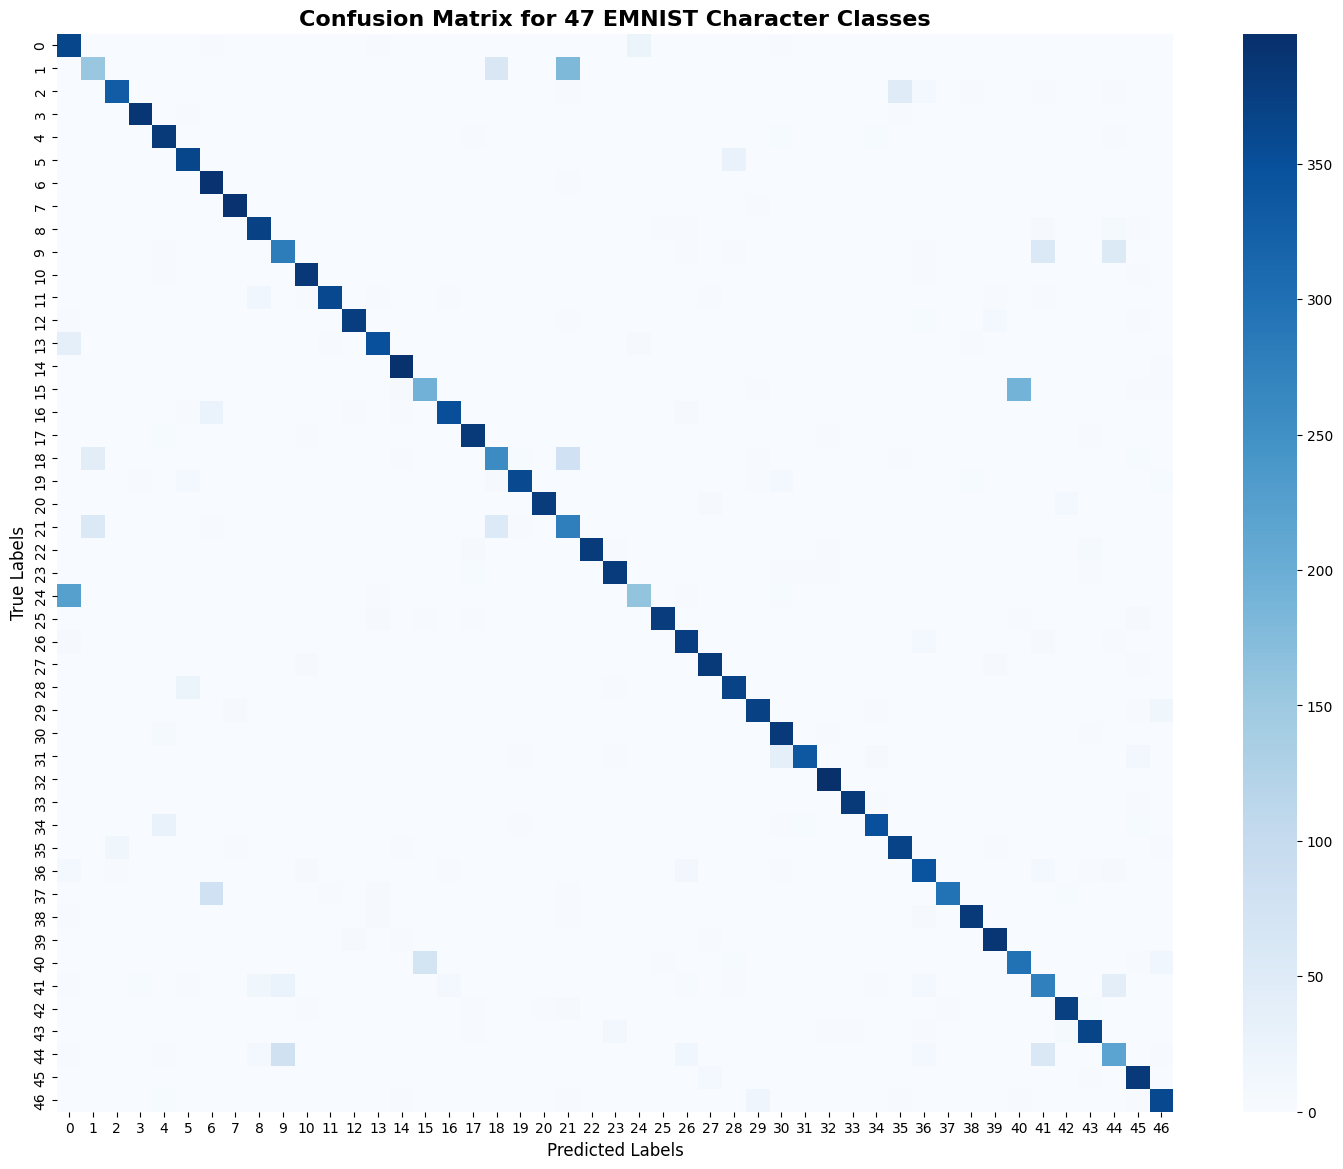

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating the model on the Test set.")

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nCLASSIFICATION REPORT")
print("\n------------------------------------------------------------")
print(classification_report(all_labels, all_preds, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 14))

sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix for 47 EMNIST Character Classes", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)

plt.show()